In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

IMAGE_SIZE = (224, 224)
BATCH_SIZE_EXP1 = 32
BATCH_SIZE_EXP2 = 128
NUM_CLASSES = 101

print(f"Wersja TensorFlow: {tf.__version__}")

Wersja TensorFlow: 2.20.0


In [ ]:
(dataset_train_raw, dataset_val_raw), ds_info = tfds.load(
    'food101',
    split=['train[:10%]', 'validation[:10%]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

def preprocess_img(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Zbiory dla Eksperymentów 1 i 3 (Batch Size = 32)
train_ds_32 = dataset_train_raw.map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds_32 = dataset_val_raw.map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

# Zbiory dla Eksperymentu 2 (Batch Size = 128)
train_ds_128 = dataset_train_raw.map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE).batch(128).prefetch(tf.data.AUTOTUNE)
val_ds_128 = dataset_val_raw.map(preprocess_img, num_parallel_calls=tf.data.AUTOTUNE).batch(128).prefetch(tf.data.AUTOTUNE)

augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
])

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.78KBMK_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.78KBMK_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [ ]:
def create_model(learning_rate, fine_tune=False):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    if fine_tune:
        base_model.trainable = True
        for layer in base_model.layers[:-30]:
            layer.trainable = False
    else:
        base_model.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model, base_model

In [ ]:
print("Rozpoczynam Eksperyment 1: LR=0.001, Batch=32, Zamrożona baza")
model_exp1, _ = create_model(learning_rate=0.001, fine_tune=False)

history_exp1 = model_exp1.fit(
    train_ds_32,
    validation_data=val_ds_32,
    epochs=5
)

Rozpoczynam Eksperyment 1: LR=0.001, Batch=32, Zamrożona baza
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 511s 2s/step - accuracy: 0.0457 - loss: 4.4310 - val_accuracy: 0.1414 - val_loss: 3.8255
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - accuracy: 0.1287 - loss: 3.8064 - val_accuracy: 0.2590 - val_loss: 3.1784
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 548s 2s/step - accuracy: 0.1789 - loss: 3.4438 - val_accuracy: 0.3283 - val_loss: 2.8338
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 533s 2s/step - accuracy: 0.2231 - loss: 3.2309 - val_accuracy: 0.3473 - val_loss: 2.6816
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 533s 2s/step - accuracy: 0.2465 - loss: 3.0959 - val_accuracy: 0.3699 - val_loss: 2.5679


In [ ]:
print("Rozpoczynam Eksperyment 2: LR=0.001, Batch=128, Zamrożona baza")
model_exp2, _ = create_model(learning_rate=0.001, fine_tune=False)

history_exp2 = model_exp2.fit(
    train_ds_128,
    validation_data=val_ds_128,
    epochs=5
)

Rozpoczynam Eksperyment 2: LR=0.001, Batch=128, Zamrożona baza
Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 591s 10s/step - accuracy: 0.0309 - loss: 4.5730 - val_accuracy: 0.0966 - val_loss: 4.2864
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 578s 10s/step - accuracy: 0.0900 - loss: 4.1278 - val_accuracy: 0.2032 - val_loss: 3.6269
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 576s 10s/step - accuracy: 0.1580 - loss: 3.6670 - val_accuracy: 0.2943 - val_loss: 3.1534
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 630s 10s/step - accuracy: 0.2074 - loss: 3.3488 - val_accuracy: 0.3370 - val_loss: 2.8659
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 579s 10s/step - accuracy: 0.2504 - loss: 3.1244 - val_accuracy: 0.3541 - val_loss: 2.6833


In [ ]:
print("Rozpoczynam Eksperyment 3: Fine-Tuning (odblokowane 30 warstw, LR=1e-5, Batch=32)")

base_model_exp1 = model_exp1.layers[2]
base_model_exp1.trainable = True
for layer in base_model_exp1.layers[:-30]:
    layer.trainable = False

model_exp1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_exp3 = model_exp1.fit(
    train_ds_32,
    validation_data=val_ds_32,
    epochs=5
)

Rozpoczynam Eksperyment 3: Fine-Tuning (odblokowane 30 warstw, LR=1e-5, Batch=32)
Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 640s 3s/step - accuracy: 0.1727 - loss: 3.5658 - val_accuracy: 0.3648 - val_loss: 2.5511
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 624s 3s/step - accuracy: 0.2191 - loss: 3.2687 - val_accuracy: 0.3774 - val_loss: 2.5201
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 648s 3s/step - accuracy: 0.2329 - loss: 3.1744 - val_accuracy: 0.3818 - val_loss: 2.5013
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 613s 3s/step - accuracy: 0.2516 - loss: 3.0934 - val_accuracy: 0.3881 - val_loss: 2.4811
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 647s 3s/step - accuracy: 0.2577 - loss: 3.0406 - val_accuracy: 0.3909 - val_loss: 2.4598


Wyniki Eksperymentu 1:


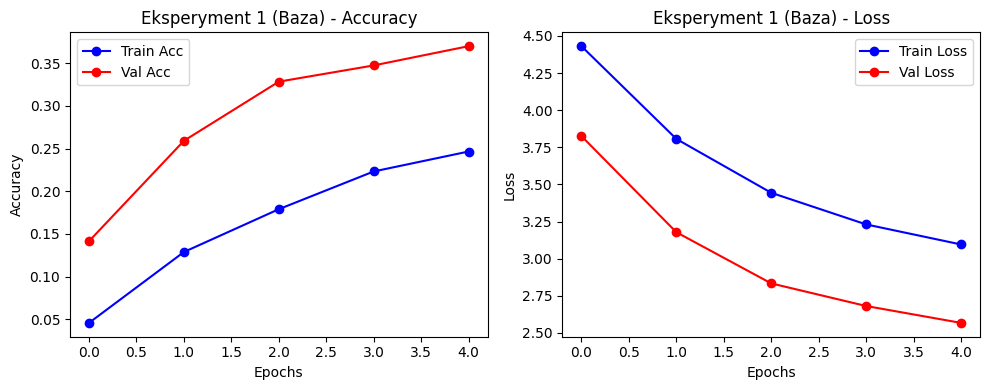

Wyniki Eksperymentu 2:


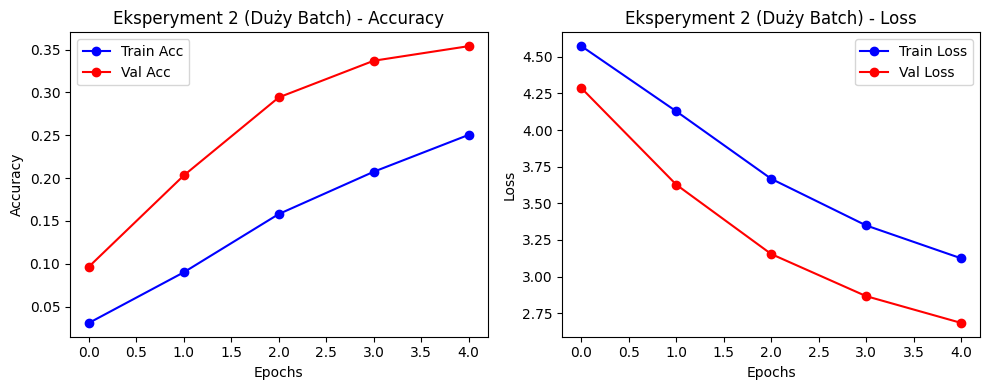

Wyniki Eksperymentu 3:


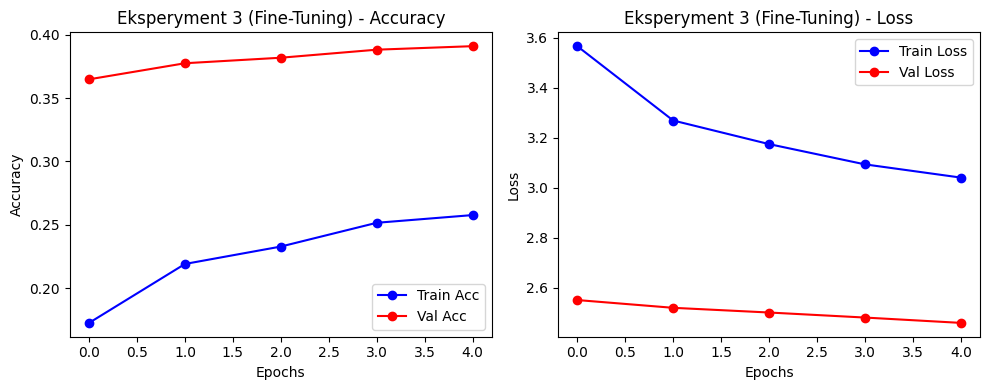

In [ ]:
def plot_accuracy_loss(history, title=""):
    plt.figure(figsize=(10, 4))

    # Wykres Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], 'bo-', label="Train Acc")
    plt.plot(history.history['val_accuracy'], 'ro-', label="Val Acc")
    plt.title(f"{title} - Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

    # Wykres Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], 'bo-', label="Train Loss")
    plt.plot(history.history['val_loss'], 'ro-', label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.ylabel("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.tight_layout()
    plt.show()

print("Wyniki Eksperymentu 1:")
plot_accuracy_loss(history_exp1, "Eksperyment 1 (Baza)")

print("Wyniki Eksperymentu 2:")
plot_accuracy_loss(history_exp2, "Eksperyment 2 (Duży Batch)")

print("Wyniki Eksperymentu 3:")
plot_accuracy_loss(history_exp3, "Eksperyment 3 (Fine-Tuning)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Znaleziono 18 błędnych predykcji w tym batchu.


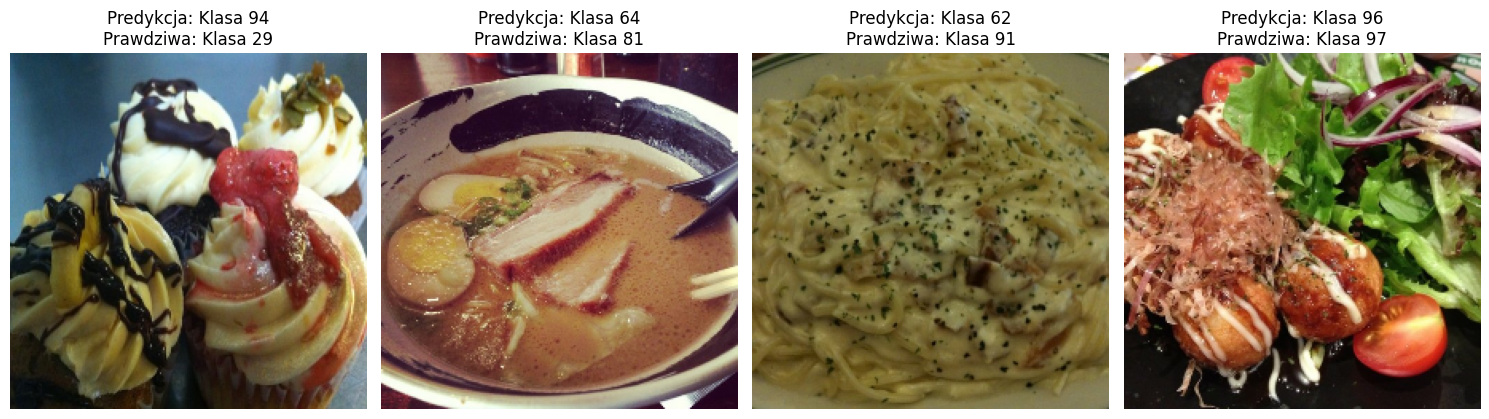

In [ ]:
val_images, val_labels = next(iter(val_ds_32))

# Generowanie przewidywań
predictions = model_exp1.predict(val_images)
predicted_classes = np.argmax(predictions, axis=1)

# Identyfikacja błędów
val_labels_numpy = val_labels.numpy()
incorrect_indices = np.where(predicted_classes != val_labels_numpy)[0]

print(f"Znaleziono {len(incorrect_indices)} błędnych predykcji w tym batchu.")

if len(incorrect_indices) > 0:
    plt.figure(figsize=(15, 5))
    for i, incorrect_idx in enumerate(incorrect_indices[:4]):
        plt.subplot(1, 4, i+1)
        plt.imshow(val_images[incorrect_idx])
        plt.title(f"Predykcja: Klasa {predicted_classes[incorrect_idx]}\nPrawdziwa: Klasa {val_labels_numpy[incorrect_idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Gratulacje, brak błędów w tym batchu!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


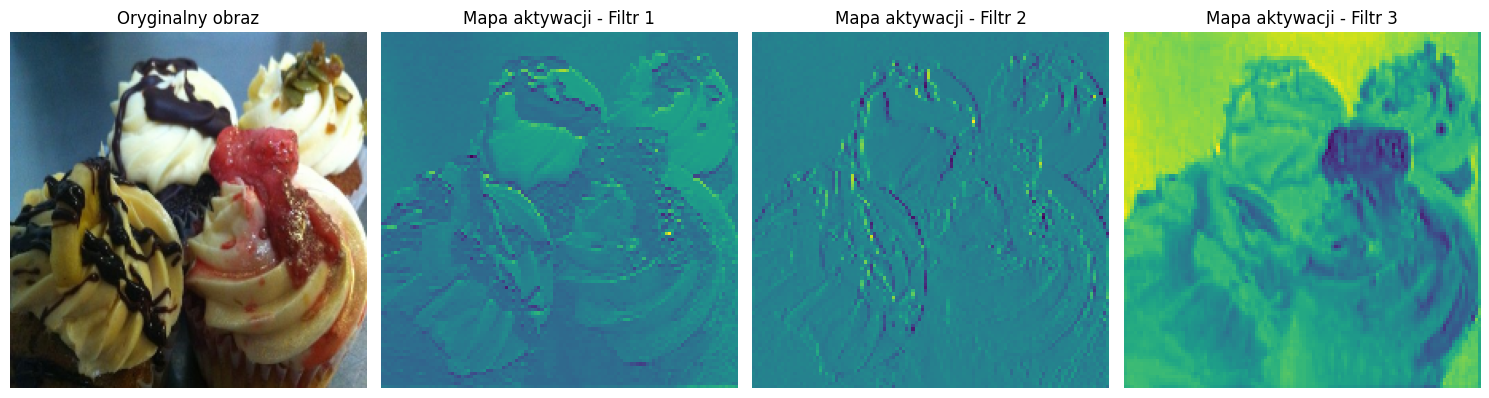

In [ ]:
sample_image = val_images[0]
sample_image_batch = tf.expand_dims(sample_image, axis=0)

base_model_reference = model_exp1.layers[2]
layer_name = 'Conv1'

feature_extractor = tf.keras.Model(
    inputs=base_model_reference.inputs,
    outputs=base_model_reference.get_layer(layer_name).output
)

feature_maps = feature_extractor.predict(sample_image_batch)

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(sample_image)
plt.title("Oryginalny obraz")
plt.axis('off')

for i in range(3):
    plt.subplot(1, 4, i+2)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f"Mapa aktywacji - Filtr {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()